# Classification model selection

## Data Preprocessing

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
dataset = pd.read_csv("Data.csv")
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


In [78]:
dataset.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


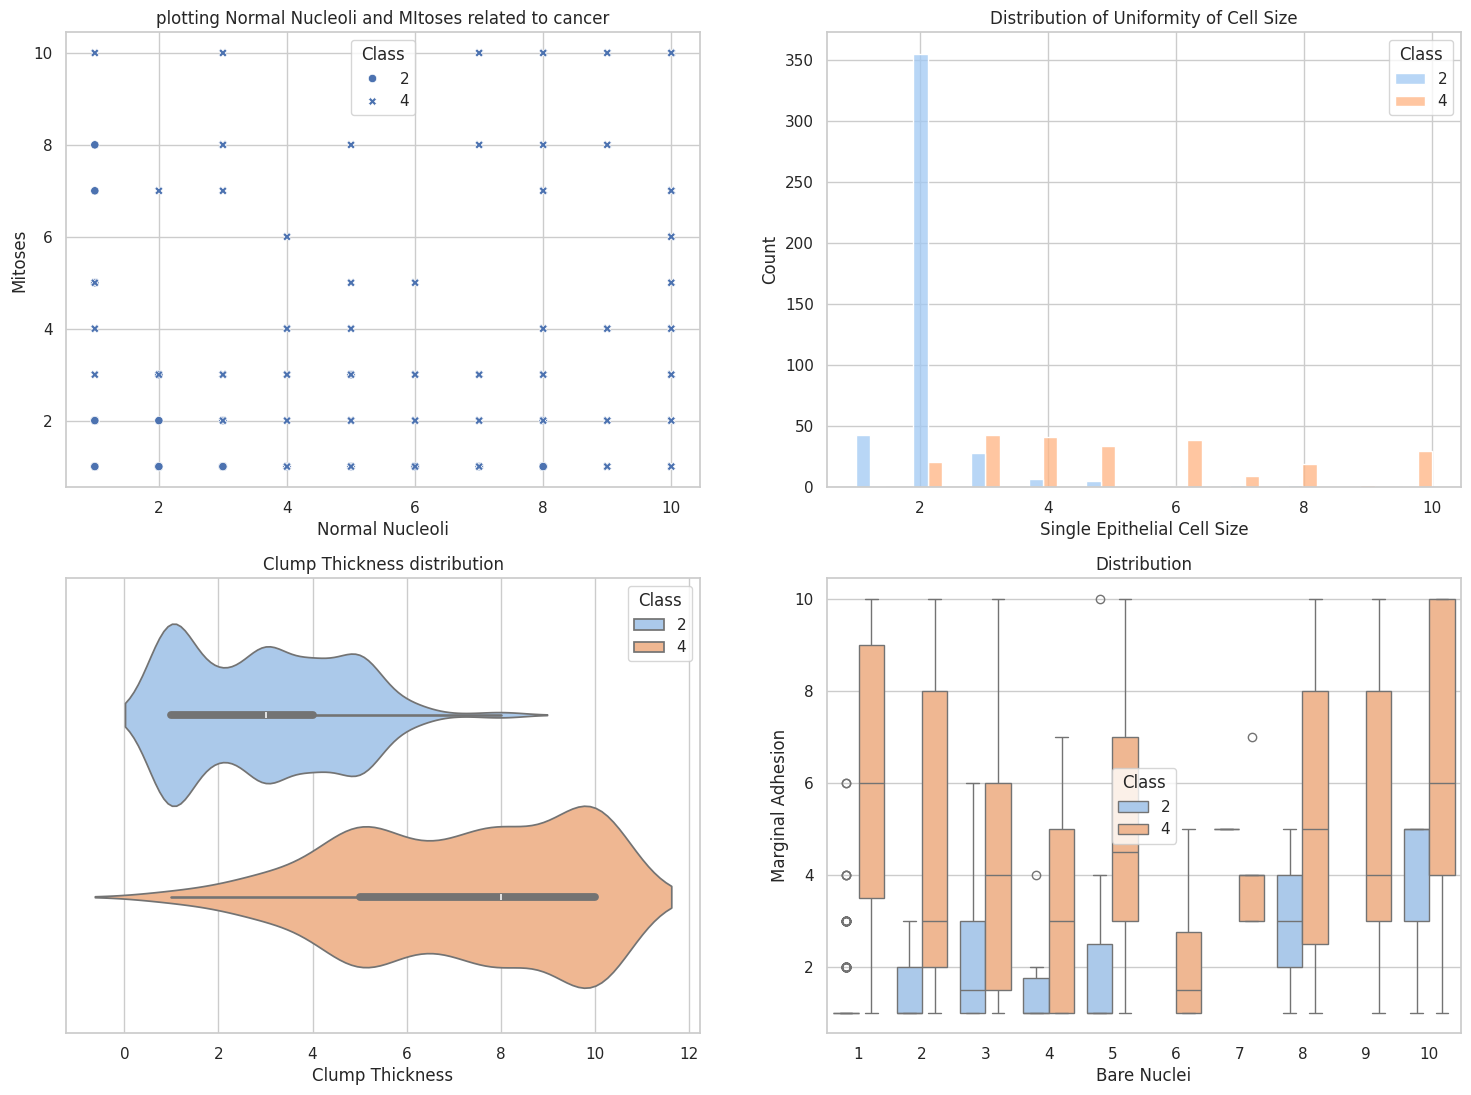

In [79]:
# Dataset visualize
import seaborn as sns

fig, axe = plt.subplots(2, 2, figsize=(18, 13))

sns.set_theme(style="whitegrid")
sns.color_palette("rocket")

sns.scatterplot(dataset, x='Normal Nucleoli', y='Mitoses', style='Class', ax=axe[0, 0])
axe[0, 0].set_title("plotting Normal Nucleoli and MItoses related to cancer")

sns.histplot(dataset, x='Single Epithelial Cell Size', ax=axe[0, 1], hue="Class", palette="pastel", multiple="dodge")
axe[0, 1].set_title("Distribution of Uniformity of Cell Size")

sns.violinplot(dataset, x="Clump Thickness", hue="Class", ax=axe[1, 0], palette="pastel")
axe[1, 0].set_title("Clump Thickness distribution")

sns.boxplot(dataset, x="Bare Nuclei", y="Marginal Adhesion", hue="Class", ax=axe[1, 1], palette="pastel")
axe[1, 1].set_title("Distribution")

plt.show()

In [80]:
# Split data into train and test set
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [81]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

## Model training

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_model = LogisticRegression(random_state=0)
neighbor_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
svc_model = SVC(kernel="linear", random_state=0)
rbf_model = SVC(kernel="rbf", random_state=0)
naive_model = GaussianNB()
tree_model = DecisionTreeClassifier(criterion='entropy', random_state=0)
forest_model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)



In [83]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
def model_evaluation(model):
  model.fit(x_train_scaled, y_train)
  y_pred = model.predict(x_test_scaled)

  cm = confusion_matrix(y_test, y_pred)
  accuracy = accuracy_score(y_test, y_pred)

  sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
  plt.title(f"Confusion matrix on {model.__class__.__name__}")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()
  print(classification_report(y_test, y_pred))

  return cm, accuracy

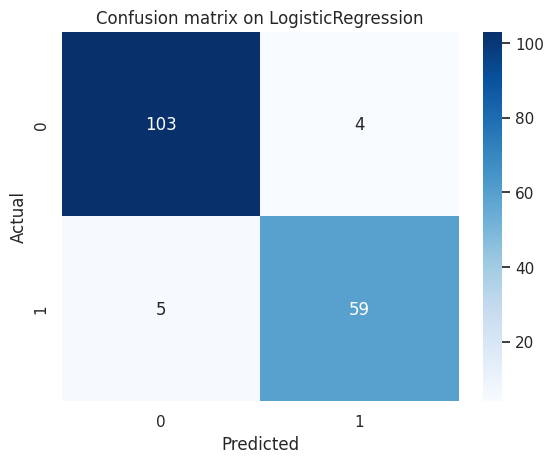

              precision    recall  f1-score   support

           2       0.95      0.96      0.96       107
           4       0.94      0.92      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



In [84]:
logistic_cm, logistic_acc= model_evaluation(logistic_model)

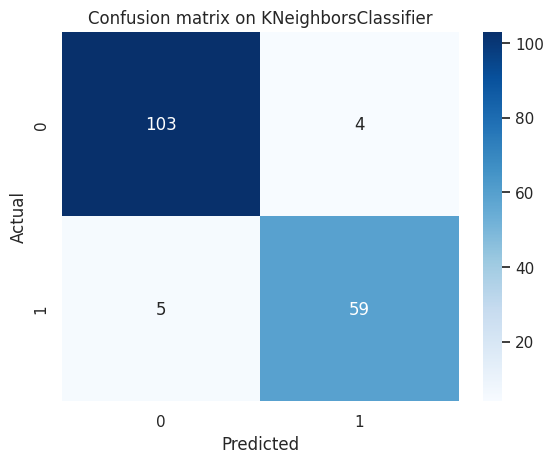

              precision    recall  f1-score   support

           2       0.95      0.96      0.96       107
           4       0.94      0.92      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



In [85]:
neighbor_cm, neighbor_acc= model_evaluation(neighbor_model)

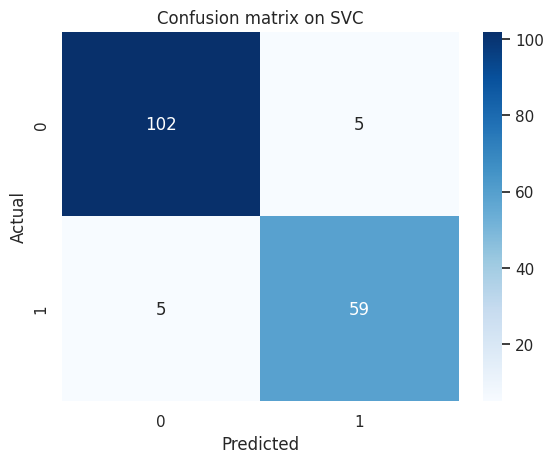

              precision    recall  f1-score   support

           2       0.95      0.95      0.95       107
           4       0.92      0.92      0.92        64

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



In [86]:
svc_cm, svc_acc= model_evaluation(svc_model)

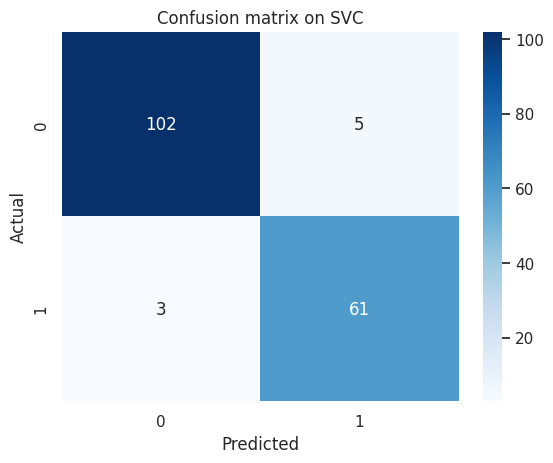

              precision    recall  f1-score   support

           2       0.97      0.95      0.96       107
           4       0.92      0.95      0.94        64

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



In [87]:
rbf_cm, rbf_acc= model_evaluation(rbf_model)

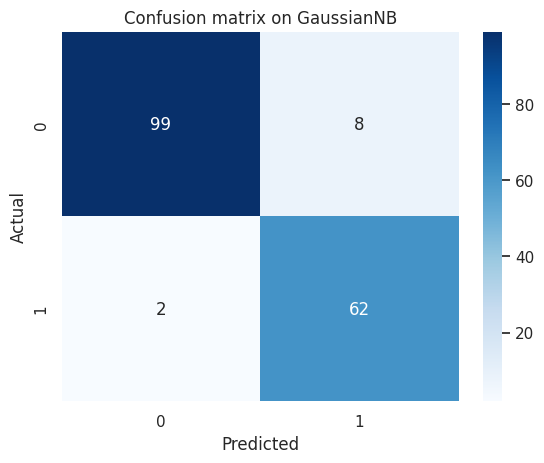

              precision    recall  f1-score   support

           2       0.98      0.93      0.95       107
           4       0.89      0.97      0.93        64

    accuracy                           0.94       171
   macro avg       0.93      0.95      0.94       171
weighted avg       0.94      0.94      0.94       171



In [88]:
naive_cm, naive_acc= model_evaluation(naive_model)

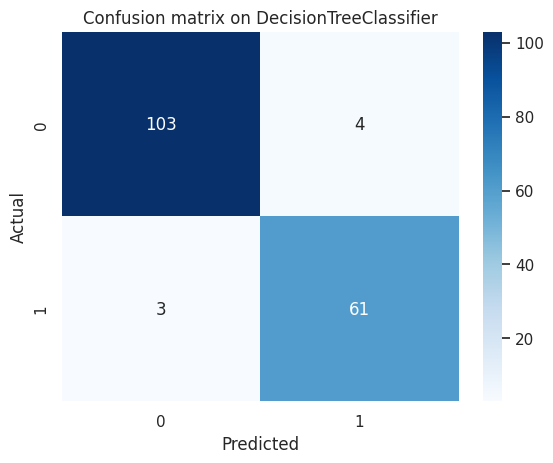

              precision    recall  f1-score   support

           2       0.97      0.96      0.97       107
           4       0.94      0.95      0.95        64

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [89]:
tree_cm, tree_acc= model_evaluation(tree_model)

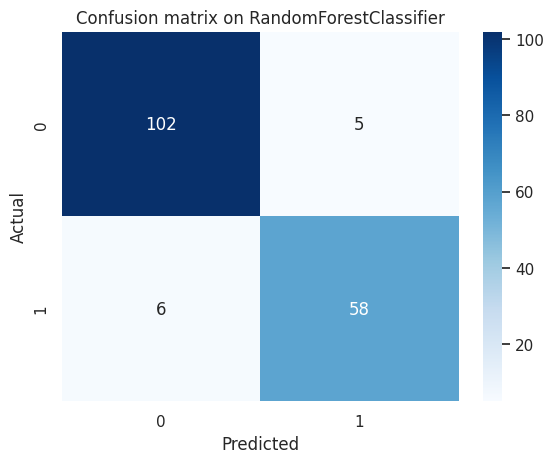

              precision    recall  f1-score   support

           2       0.94      0.95      0.95       107
           4       0.92      0.91      0.91        64

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



In [90]:
forest_cm, forest_acc= model_evaluation(forest_model)

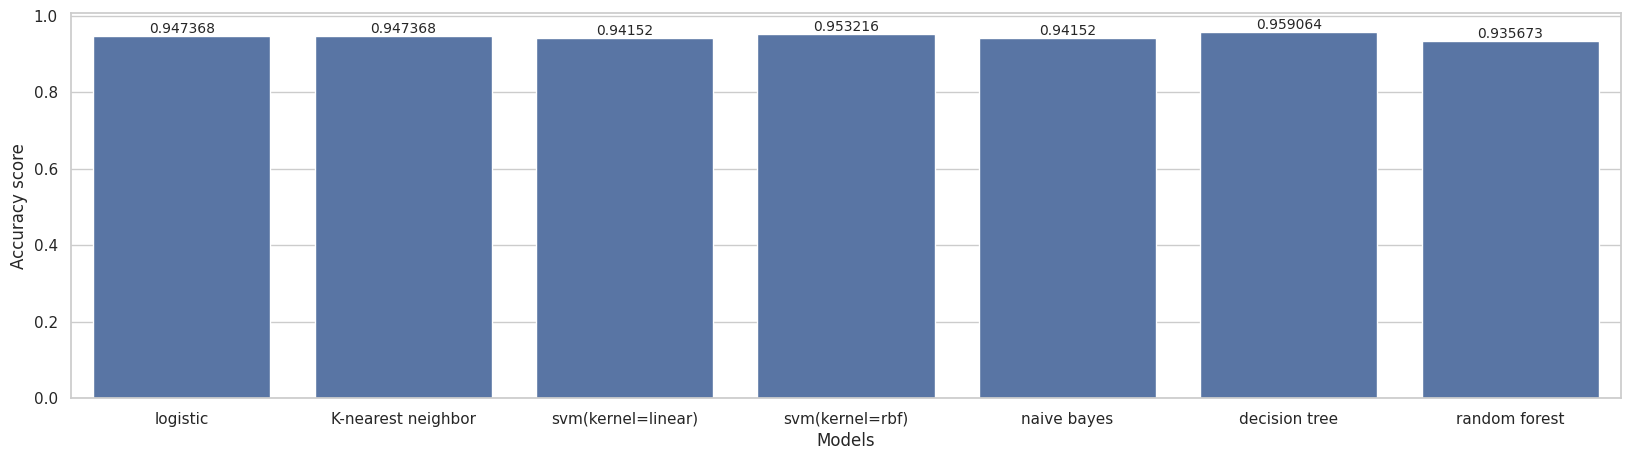

In [92]:
plt.subplots(figsize=(20, 5))
ax = sns.barplot(x=["logistic", "K-nearest neighbor", "svm(kernel=linear)", "svm(kernel=rbf)", "naive bayes","decision tree", "random forest"],
                 y=[logistic_acc, neighbor_acc, svc_acc, rbf_acc, naive_acc,tree_acc, forest_acc])
ax.bar_label(ax.containers[0], fontsize=10);
plt.ylabel("Accuracy score")
plt.xlabel("Models")
plt.show()